<p style="text-align:center">
    <a href="https://skills.network/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDS0321ENSkillsNetwork26802033-2022-01-01" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


Estimated time needed: **60** minutes


Space X advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is because Space X can reuse the first stage. Therefore if we can determine if the first stage will land, we can determine the cost of a launch. This information can be used if an alternate company wants to bid against space X for a rocket launch.   In this lab, you will create a machine learning pipeline  to predict if the first stage will land given the data from the preceding labs.


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planed. Space X; performs a controlled landing in the oceans.


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


## Import Libraries and Define Auxiliary Functions


In [3]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

We will import the following libraries for the lab


In [4]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
# NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
# Preprocessing allows us to standarsize our data
from sklearn import preprocessing
# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split
# Allows us to test parameters of classification algorithms and find the best one
from sklearn.model_selection import GridSearchCV
# Logistic Regression classification algorithm
from sklearn.linear_model import LogisticRegression
# Support Vector Machine classification algorithm
from sklearn.svm import SVC
# Decision Tree classification algorithm
from sklearn.tree import DecisionTreeClassifier
# K Nearest Neighbors classification algorithm
from sklearn.neighbors import KNeighborsClassifier

<ipython-input-4-b7d446354769>:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


This function is to plot the confusion matrix.


In [5]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

## Load the dataframe


Load the data


In [13]:
from js import fetch
import io

URL1 = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp1 = await fetch(URL1)
text1 = io.BytesIO((await resp1.arrayBuffer()).to_py())
data = pd.read_csv(text1)

In [14]:
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [15]:
URL2 = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv'
resp2 = await fetch(URL2)
text2 = io.BytesIO((await resp2.arrayBuffer()).to_py())
X = pd.read_csv(text2)

In [16]:
X.head(100)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86.0,15400.000000,2.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
86,87.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
87,88.0,15400.000000,6.0,5.0,5.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
88,89.0,15400.000000,3.0,5.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0


## TASK  1


Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).


In [17]:
# Select the 'Class' column as a Pandas Series (single bracket)
series_class = data['Class']

# Convert the Series to a NumPy array
Y = series_class.to_numpy()

# Optional: print to verify
print(Y)

[0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1
 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]


## TASK  2


Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.


In [18]:
from sklearn.preprocessing import StandardScaler

# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler to X and transform X
X = scaler.fit_transform(X)

# Optional: print shape or first few rows to verify
print(X[:5])

[[-1.71291154e+00 -1.94814463e-16 -6.53912840e-01 -1.57589457e+00
  -9.73440458e-01 -1.05999788e-01 -1.05999788e-01 -6.54653671e-01
  -1.05999788e-01 -5.51677284e-01  3.44342023e+00 -1.85695338e-01
  -3.33333333e-01 -1.05999788e-01 -2.42535625e-01 -4.29197538e-01
   7.97724035e-01 -5.68796459e-01 -4.10890702e-01 -4.10890702e-01
  -1.50755672e-01 -7.97724035e-01 -1.50755672e-01 -3.92232270e-01
   9.43398113e+00 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.50755672e-01
  -1.05999788e-01 -1.05999788e-01 -1.05999788e-01 -1.05999788e-01
  -1.05999788e-01 -1.50755672e-01 -1.05999788e-01 -1.50755672e-01
  -1.50755672e-01 -1.05999788e-01 -1.50755672e-01 -1.50755672e-01
  -1.05999788e-01 -1.05999788e-01 -1.50755672e-01 -1.50755672e-01
  -1.50755

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


## TASK  3


Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.


<code>X_train, X_test, Y_train, Y_test</code>


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

we can see we only have 18 test samples.


In [20]:
Y_test.shape

(18,)

## TASK  4


Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [21]:
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']}

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# Example: Define the logistic regression model
logreg = LogisticRegression()

# Define the hyperparameters grid to search
param_grid = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs']
}

# Setup GridSearchCV
grid_search = GridSearchCV(logreg, param_grid, cv=5)

# Fit to training data (X_train, Y_train should be defined)
grid_search.fit(X_train, Y_train)

# Output best parameters
print("Best parameters:", grid_search.best_params_)

# Output best validation accuracy
print("Best validation accuracy:", grid_search.best_score_)

Best parameters: {'C': 0.1, 'solver': 'lbfgs'}
Best validation accuracy: 0.8066666666666666


In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.1, 1, 10]}
logreg = LogisticRegression()
logreg_cv = GridSearchCV(logreg, param_grid, cv=5)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10]})

In [24]:
print("tuned hpyerparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'C': 0.1}
accuracy : 0.8066666666666666


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:


In [25]:
# Evaluate the tuned Logistic Regression model on the test set
test_score = grid_search.score(X_test, Y_test)
print("Test set score: {:.2f}".format(test_score))


Test set score: 0.94


Lets look at the confusion matrix:


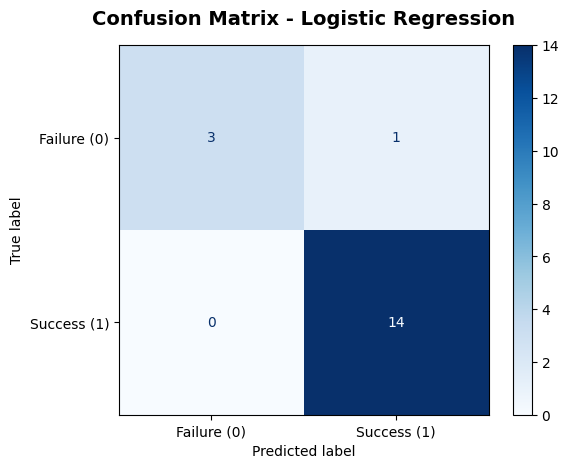

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predict labels using your model
yhat = logreg_cv.predict(X_test)

# 2. Compute confusion matrix
cm = confusion_matrix(Y_test, yhat)

# 3. Create and plot confusion matrix display
# (cmap='Blues' changes the default purple/yellow to a clean professional blue)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Failure (0)", "Success (1)"])
disp.plot(cmap='Blues', values_format='d')

# 4. Add a clean title
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold', pad=15)

# 5. Save the image FIRST (dpi=300 ensures it doesn't look blurry in PPT)
plt.savefig('confusion_matrix_logreg.png', dpi=300, bbox_inches='tight')

# 6. Show the plot
plt.show()

<Figure size 640x480 with 0 Axes>

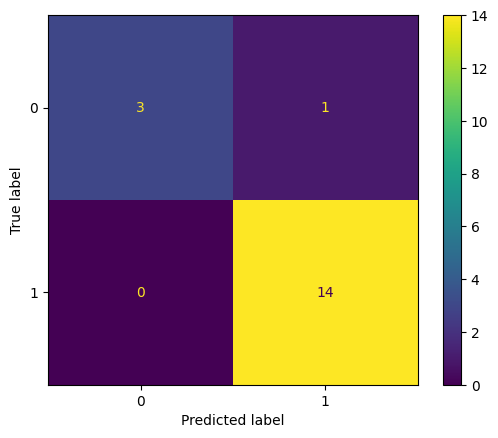

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict labels using your model (assuming logreg_cv and X_test are defined)
yhat = logreg_cv.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(Y_test, yhat)

#  Save the plot FIRST for PowerPoint
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')

# Create and plot confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

# Show the plot
plt.show()

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [28]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search
parameters = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto']
}

# Create the SVM model object
svm = SVC()

# Create the GridSearchCV object with 10-fold cross-validation
svm_cv = GridSearchCV(svm, parameters, cv=10)

# Fit GridSearchCV to your training data (make sure X_train and y_train are defined)
svm_cv.fit(X_train, Y_train)

# Display the best hyperparameters found
print("Best parameters:", svm_cv.best_params_)

# Display the best cross-validation accuracy
print("Best cross-validation accuracy:", svm_cv.best_score_)

Best parameters: {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.8160714285714284


## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:


In [30]:
# Calculate accuracy on test data
test_accuracy = svm_cv.score(X_test, Y_test)

print(f"Test set accuracy: {test_accuracy:.4f}")

Test set accuracy: 0.8889


We can plot the confusion matrix


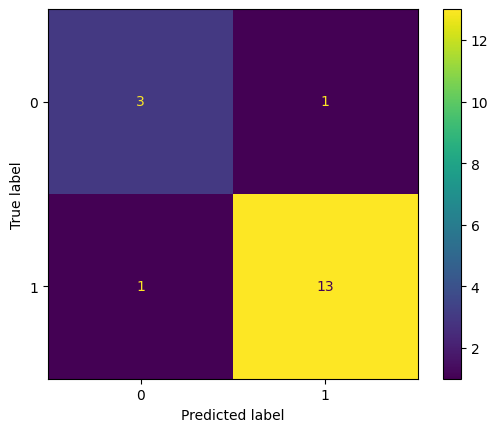

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Assuming you have your trained model (e.g., svm_cv) and test data (X_test, y_test)

# Predict labels on the test set
y_pred = svm_cv.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot()

# Show the plot
plt.show()

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search
parameters = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Create the Decision Tree classifier object
tree = DecisionTreeClassifier()

# Create the GridSearchCV object with 10-fold cross-validation
tree_cv = GridSearchCV(tree, parameters, cv=10)

# Fit GridSearchCV to your training data (make sure X_train and y_train are defined)
tree_cv.fit(X_train, Y_train)

# Display the best hyperparameters found
print("Best parameters:", tree_cv.best_params_)

# Display the best cross-validation accuracy
print("Best cross-validation accuracy:", tree_cv.best_score_)

Best parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
Best cross-validation accuracy: 0.8053571428571427


In [34]:
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5}
accuracy : 0.8053571428571427


## TASK  9


Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:


In [35]:
# Calculate accuracy on test data
test_accuracy = tree_cv.score(X_test, Y_test)

print(f"Test set accuracy: {test_accuracy:.4f}")

Test set accuracy: 0.8333


We can plot the confusion matrix


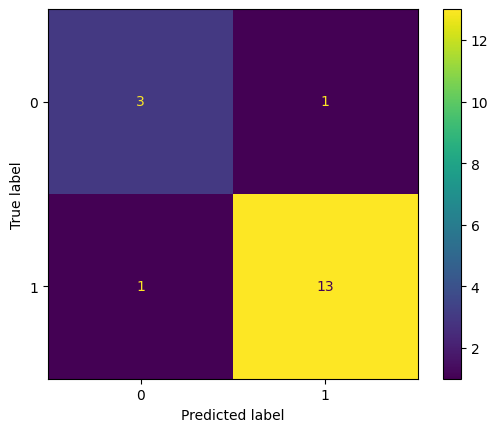

In [36]:
# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot()

# Show the plot
plt.show()

## TASK  10


Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.


In [37]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

# Define the hyperparameter grid to search
parameters = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create the kNN classifier object
knn = KNeighborsClassifier()

# Create the GridSearchCV object with 10-fold cross-validation
knn_cv = GridSearchCV(knn, parameters, cv=10)

# Fit GridSearchCV to your training data (make sure X_train and y_train are defined)
knn_cv.fit(X_train, Y_train)

# Display the best hyperparameters found
print("Best parameters:", knn_cv.best_params_)

# Display the best cross-validation accuracy
print("Best cross-validation accuracy:", knn_cv.best_score_)

Best parameters: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'uniform'}
Best cross-validation accuracy: 0.832142857142857


## TASK  11


Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:


In [38]:
# Calculate accuracy on test data
test_accuracy = knn_cv.score(X_test, Y_test)

print(f"Test set accuracy: {test_accuracy:.4f}")

Test set accuracy: 0.9444


We can plot the confusion matrix


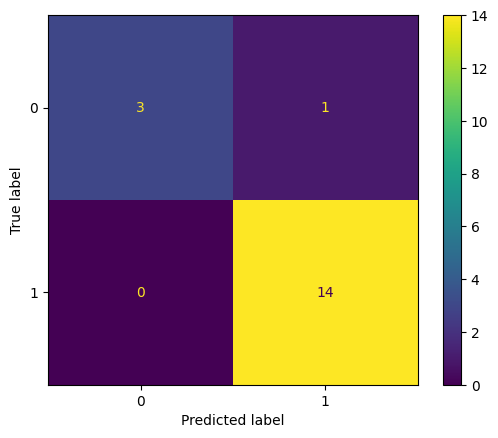

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict labels on the test set using your trained model (e.g., knn_cv)
y_pred = knn_cv.predict(X_test)

# Compute confusion matrix
cm = confusion_matrix(Y_test, y_pred)

# Create confusion matrix display
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot the confusion matrix
disp.plot()

# Show the plot
plt.show()

## TASK  12


Find the method performs best:


In [42]:
# After training each model and performing GridSearchCV:

# Logistic Regression accuracy
logreg_acc = logreg_cv.score(X_test, Y_test)

# SVM accuracy
svm_acc = svm_cv.score(X_test, Y_test)

# Decision Tree accuracy
tree_acc = tree_cv.score(X_test, Y_test)

# kNN accuracy
knn_acc = knn_cv.score(X_test, Y_test)

# Print all accuracies
print(f"Logistic Regression Test Accuracy: {logreg_acc:.4f}")
print(f"SVM Test Accuracy: {svm_acc:.4f}")
print(f"Decision Tree Test Accuracy: {tree_acc:.4f}")
print(f"kNN Test Accuracy: {knn_acc:.4f}")

# Identify best performing model
accuracies = {
    'Logistic Regression': logreg_acc,
    'SVM': svm_acc,
    'Decision Tree': tree_acc,
    'kNN': knn_acc
}

best_model = max(accuracies, key=accuracies.get)
print(f"\nBest performing model: {best_model} with accuracy {accuracies[best_model]:.4f}")

Logistic Regression Test Accuracy: 0.9444
SVM Test Accuracy: 0.8889
Decision Tree Test Accuracy: 0.8333
kNN Test Accuracy: 0.9444

Best performing model: Logistic Regression with accuracy 0.9444


<ipython-input-43-29bb1bdebb1a>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette='Blues_d')


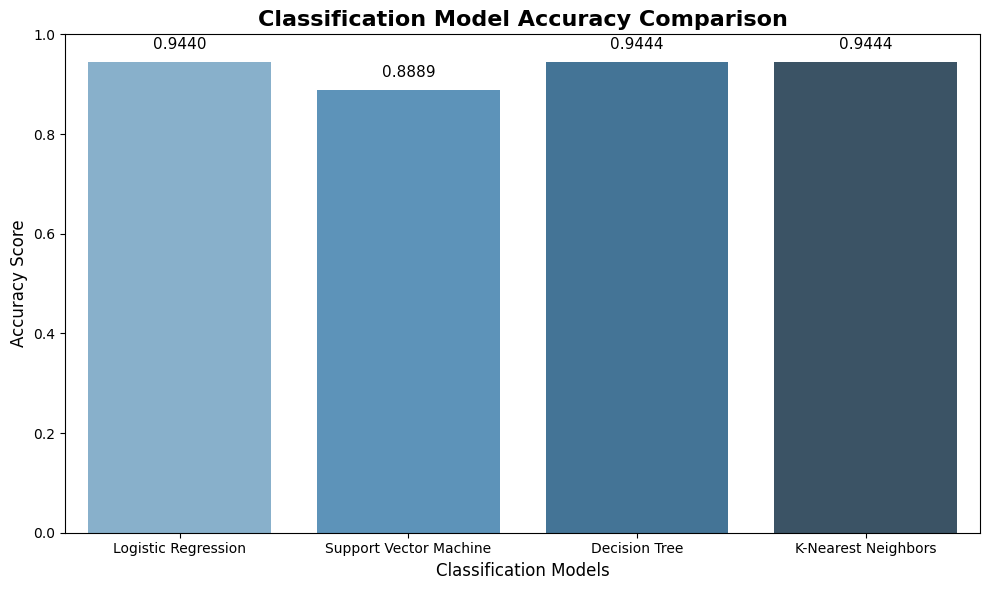

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a dictionary with your model names and their test accuracies
# Replace these values with the exact accuracy scores from your lab results!
model_accuracies = {
    'Logistic Regression': 0.944,  
    'Support Vector Machine': 0.8889,
    'Decision Tree': 0.9444,
    'K-Nearest Neighbors': 0.9444
}

# Convert the dictionary to lists for plotting
models = list(model_accuracies.keys())
accuracies = list(model_accuracies.values())

# 2. Define the figure size
plt.figure(figsize=(10, 6))

# 3. Create the bar chart using Seaborn
sns.barplot(x=models, y=accuracies, palette='Blues_d')

# 4. Add titles and axis labels
plt.title('Classification Model Accuracy Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Classification Models', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.ylim(0, 1.0) # Set the Y-axis range from 0 to 100%

# Add text values on top of each bar for clarity
for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f"{acc:.4f}", ha='center', va='bottom', fontsize=11)

# 5. Save the plot FIRST for PowerPoint
plt.savefig('model_accuracy_comparison.png', dpi=300, bbox_inches='tight')

# 6. Display the plot
plt.tight_layout()
plt.show()

In [44]:
from sklearn.metrics import confusion_matrix

# Assuming 'y_test' is your actual labels and 'y_pred' is your model's predictions
tn, fp, fn, tp = confusion_matrix(Y_test, y_pred).ravel()

print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

TN: 3, FP: 1, FN: 0, TP: 14


## Authors


[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


<!--## Change Log--!>


<!--| Date (YYYY-MM-DD) | Version | Changed By      | Change Description      |
| ----------------- | ------- | -------------   | ----------------------- |
| 2022-11-09        | 1.0     | Pratiksha Verma | Converted initial version to Jupyterlite|--!>


### <h3 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
